In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA MAHASISWA
    Nama  SosialMedia  Belajar  Streaming  Game  Tidur
0   Andi            4        6          2     1      7
1   Budi            5        4          3     2      6
2  Citra            2        8          1     1      8
3   Dewi            6        3          2     3      7
4    Eko            3        7          2     2      8
5   Fani            7        2          4     3      6
6   Gita            2        9          1     1      8
7   Hadi            4        5          2     2      7

===== RATA-RATA =====
Sosial Media : 4.12
Belajar : 5.50
Streaming : 2.12
Game : 1.88
Tidur : 7.12
===== PRODUKTIVITAS =====
Tertinggi : Gita - 29
Terendah : Fani - -8
===== SOSIAL MEDIA TERTINGGI =====
Fani - 7 jam


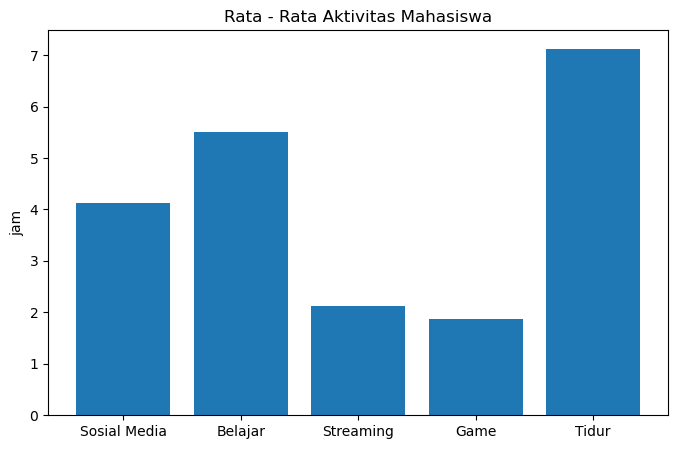

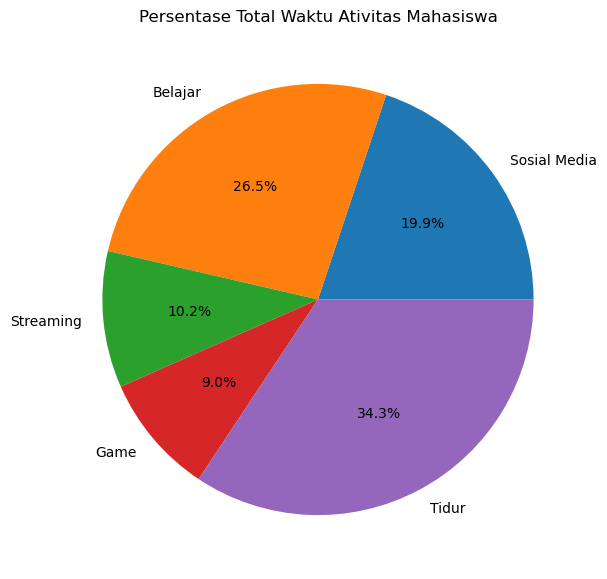

In [ ]:
class Mahasiswa: ##Membuat Class Mahasiswa berisi function didalamnya
    def __init__(self, nama, sosial_media, belajar, streaming, game, tidur): ##konstruktor dengan parameter self, nama, sosial_media, belajar, streaming, game, tidur
        self.nama = nama ##menyimpan nama
        self.sosial_media = sosial_media ## menyimpan lama sosial media
        self.belajar = belajar ## menyimpan lama belajar 
        self.streaming = streaming ## menyimpan lama streaming
        self.game = game ## menyimpan lama game
        self.tidur = tidur ## menyimpan lama tidur

    def hitung_produktivitas(self): ##fungsi untuk menghitung produktivitas mahasiswa
        skor = (self.belajar*3) + (self.tidur*1) - (self.sosial_media*2) - (self.game*2) ##perhitungan produktivitas
        return skor ##mengembalikan nilai ke skor

def baca_data(): ##fungsi untuk membaca data awal csv
    return pd.read_csv('aktivitas_mahasiswa.csv') ##Mengembalikan data yang dibaca di csv

def tambah_data(df): ##fungsi untuk menambah data mahasiswa
    print("Tambah Data Mahasiswa") ##menampilkan tulisan ke layar
    nama = input("Nama Mahasiswa :") ##meminta user mengisi nama baru
    sosial = int(input("Lama Penggunaan Sosial Media (jam) :")) ##meminta user men  gisi lama penggunaan sosial media
    belajar = int(input("Lama Belajar Menggunakan Laptop (jam) :")) ##meminta user mengisi lama belajar
    streaming = int(input("Lama Menonton Video Streaming (jam) :")) ##meminta user mengisi lama menonton streaming
    game = int(input("Lama Bermain Game  (jam) :")) ##meminta user mengisi lama bermain game
    tidur = int(input("Lama Tidur (jam) :")) ##meminta user mengisi lama tidur

    data_baru = pd.DataFrame({'Nama':[nama], 'SosialMedia':[sosial], 'Belajar':[belajar], ##membuat dataframe baru berdasarkan input dari user
                              'Streaming':[streaming], 'Game':[game], 'Tidur':[tidur]}) ##mulai dari nama, lama penggunaan medsos, belajar, streaming, game dan tidur

    df = pd.concat([df ,data_baru], ignore_index =True) ##menggabungkan data baru ke data frame yang sudah ada
    df.to_csv("aktivitas_mahasiswa.csv", index = False) ##menyimpan data frame yang baru ke file csv

    print("Data Berhasil Ditambahkan!") ##menampilkan tulisan ke layar
    return df ##mengembalikan nilai df

def edit_data(df): ##fungsi untuk mengedit data mahasiswa
    nama = input("Masukkan Nama Yang Ingin Diedit :") ##meminta user memasukkan nama yang ingin dicari
    if nama in df["Nama"].values: ##jika nama yang dicari ada pada data mahasiswa
        index = df[df["Nama"] == nama].index[0] ##mengambil index mahasiswa yang namanya sesuai
        df.loc[index, "SosialMedia"] = int(input("Lama Penggunaan Sosial Media (jam) :")) ##memperbarui data dengan menginput lama penggunaan medsos
        df.loc[index, "Belajar"] = int(input("Lama Belajar Menggunakan Laptop (jam) :")) ##memperbarui data dengan menginput lama belajar
        df.loc[index, "Streaming"]  = int(input("Lama Menonton Video Streaming (jam) :")) ##memperbarui data dengan menginput lama streaming
        df.loc[index, "Game"] = int(input("Lama Bermain Game  (jam) :")) ##memperbarui data dengan menginput lama bermain game
        df.loc[index, "Tidur"] = int(input("Lama Tidur (jam) :")) ##memperbarui data dengan menginput lama tidur

        df.to_csv("aktivitas_mahasiswa.csv", index = False) ##menyimpan data yang baru ke file csv
        print("Data Berhasil Diedit!") ##menampilkan tulisan ke layar
    else: ## jika tidak ada
        print("Data Tidak Ditemukan!") ##menampilkan tulisan ke layar
    return df ## mengembalikan nilai df

def hitung_rata(df): ##fungsi untuk melihat rata-rata dari tiap kategori
    rata = {"Sosial Media": np.mean(df["SosialMedia"]), ##menghitung rata-rata kategori media sosial dari data yang ada
             "Belajar":np.mean(df["Belajar"]), ##menghitung rata-rata kategori belajar dari data yang ada
             "Streaming":np.mean(df["Streaming"]), ##menghitung rata-rata kategori streaming dari data yang ada
             "Game":np.mean(df["Game"]), ##menghitung rata-rata kategori game dari data yang ada
             "Tidur":np.mean(df["Tidur"])} ##menghitung rata-rata kategori tidur dari data yang ada
    return rata ##mengembalikan nilai rata-rata

def mahasiswa_produktif(df): ##fungsi untuk mencari mahasiswa produktif
    daftar = [] ##membuat array kosong 
    for i in range(len(df)):##perulangan untuk membaca data sepanjang banyakknya data yang ada
        mhs = Mahasiswa(
            df.loc[i, "Nama"], ##mengambil nama mahasiswa
            df.loc[i, "SosialMedia"], ##mengambil lama menggunakan medsos
            df.loc[i, "Belajar"], ##mengambil lama belajar
            df.loc[i, "Streaming"], ##mengambil lama streaming
            df.loc[i, "Game"], ##mengambil lama bermain game
            df.loc[i, "Tidur"] ##mengambil lama tidur 
        )
        skor = mhs.hitung_produktivitas() ##menghitung skor produktivitas mahasiswa
        daftar.append((mhs.nama, skor)) ##menyimpan nama dan skor ke dalam list

    terbaik = max(daftar, key=lambda x: x[1]) ##mencari mahasiswa dengan produktivitas tertinggi 
    terendah = min(daftar, key=lambda x: x[1]) ##mencari mahasiswa dengan produktivitas terendah
 
    return terbaik, terendah ##mengembalikan nilai terbaik dan terendah
    
def sosial_media_tertinggi(df): ##fungsi untuk mencari penggunaan sosmed tertinggi
    index = df["SosialMedia"].idxmax() ##mencari data tertinggi penggunaan sosmed pada kategori SosialMedia

    return(df.loc[index, "Nama"], df.loc[index, "SosialMedia"]) ##mengembalikan nama yang diambil dan sosmed yang diambil

def grafik_batang(rata): ##fungsi untuk menampilkan grafik batang
    kategori = list(rata.keys()) ## mengubah key dictionary menjadi list kategori aktivitas     
    nilai = list(rata.values()) ## mengubah value dictionary menjadi list rata-rata jam aktivitas

    plt.figure(figsize=(8, 5)) ##membuat canvas grafik 8 * 5
    plt.bar(kategori, nilai) ##menampilkan data dalam bentuk diagram  batang

    plt.title("Rata - Rata Aktivitas Mahasiswa") ##Membuat judul pada diagram
    plt.ylabel("jam") ##menampilkan jam pada nilai y

    plt.show() ##menampilkan grafik

def pie_chart(df): ##fungsi untuk menampilkan grafik pie chart
    total = [df["SosialMedia"].sum(), ##menghitung total jam sosmed
             df["Belajar"].sum(), ##menghitung total jam belajar
             df["Streaming"].sum(), ##menghitung total jam streaming
             df["Game"].sum(), ##menghitung total jam game
             df["Tidur"].sum()] ##menghitung total jam tidur
    label = ["Sosial Media", "Belajar", "Streaming", "Game", "Tidur"] ##memberi label pada diagramnya

    plt.figure(figsize = (7,7)) ##membuat canvas grafik 7 * 7
    plt.pie(total, labels=label, autopct="%1.1f%%") ##menampilkan persentase setiap aktivitas dengan 1 angka di belakang koma

    plt.title("Persentase Total Waktu Ativitas Mahasiswa") ##Membuat judul pada diagram
    plt.show() ##menampilkan grafik


##main
df = baca_data() ##memanggil fungsi baca data mahasiswa yg disimpan pada variabel df
 
print("DATA MAHASISWA") ##menampilkan tulisan
print(df) ##menampilkan isi df

rata = hitung_rata(df)  ## memanggil fungsi untuk menghitung rata-rata setiap aktivitas mahasiswa
print("\n===== RATA-RATA =====") ##menampilkan tulisan
for k, v in rata.items(): ## menampilkan setiap kategori aktivitas dan nilai rata-ratanya
    print(f"{k} : {v:.2f}")

terbaik, terendah = mahasiswa_produktif(df) ##memanggil fungsi untuk mencari mahasiswa produktif
print("===== PRODUKTIVITAS =====") ##menampilkan tulisan ke layar
print("Tertinggi :", terbaik[0], "-", terbaik[1]) ##menampilkan data tertinggi mahasiswa produktif
print("Terendah :", terendah[0], "-", terendah[1]) ##menampilkan data terendah mahasiswa produktif

nama, jam = sosial_media_tertinggi(df) ##memanggil fungsi untuk mencari pengguna sosmed tertinggi
print("===== SOSIAL MEDIA TERTINGGI =====") ##menampilkan tulisan ke layar
print(nama, "-", jam, "jam") ##mengambil data di fungsi tsb

grafik_batang(rata) ##menampilkan isi fungsi dari grafik batang
pie_chart(df) ##menampilkan isi fungsi dari pie chart